In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split


2026-03-17 16:26:16.323865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773764776.622928      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773764776.713659      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773764777.422710      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773764777.422765      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773764777.422769      55 computation_placer.cc:177] computation placer alr

In [3]:
data_dir = '/kaggle/input/datasets/ahmedhamada0/brain-tumor-detection'
groups = ['yes', 'no']
file_paths = []
labels = []

for group in groups:
    fold_path = os.path.join(data_dir, group) 
    files = os.listdir(fold_path)
    for file in files:
        file_path = os.path.join(fold_path, file)
        file_paths.append(file_path)
        labels.append(group)


In [4]:
# import os
# import shutil

# # SOURCE (dataset)
# src_yes = '/kaggle/input/datasets/ahmedhamada0/brain-tumor-detection/yes'
# src_no  = '/kaggle/input/datasets/ahmedhamada0/brain-tumor-detection/no'

# # DESTINATION (working folder)
# dst_yes = '/kaggle/working/data/train/yes'
# dst_no  = '/kaggle/working/data/train/no'

# os.makedirs(dst_yes, exist_ok=True)
# os.makedirs(dst_no, exist_ok=True)

# # Copy files
# for file in os.listdir(src_yes):
#     shutil.copy(os.path.join(src_yes, file), dst_yes)

# for file in os.listdir(src_no):
#     shutil.copy(os.path.join(src_no, file), dst_no)

In [5]:
df=pd.DataFrame({'file_paths':file_paths,
                'labels':labels})

print(df.sample(10))

print(df['labels'].value_counts())


                                             file_paths labels
218   /kaggle/input/datasets/ahmedhamada0/brain-tumo...    yes
1499  /kaggle/input/datasets/ahmedhamada0/brain-tumo...    yes
2566  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
2022  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
631   /kaggle/input/datasets/ahmedhamada0/brain-tumo...    yes
2544  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
2091  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
2524  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
2466  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
2271  /kaggle/input/datasets/ahmedhamada0/brain-tumo...     no
labels
yes    1500
no     1500
Name: count, dtype: int64


In [6]:
train_df,test_df=train_test_split(df,test_size=0.2,random_state=42,stratify=df['labels'])

In [7]:
gen=ImageDataGenerator()
train_gen=gen.flow_from_dataframe(train_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)

test_gen=gen.flow_from_dataframe(test_df, x_col='file_paths', y_col='labels', 
                                    target_size=(224, 224), color_mode='grayscale', 
                                    class_mode='binary', batch_size=16)


Found 2400 validated image filenames belonging to 2 classes.
Found 600 validated image filenames belonging to 2 classes.


In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 16:27:32.730714: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [9]:
traning = model.fit(train_gen, epochs=10, validation_data=test_gen)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.6993 - loss: 20.4835 - val_accuracy: 0.7150 - val_loss: 0.5803
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7990 - loss: 0.4514 - val_accuracy: 0.8200 - val_loss: 0.4296
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 162s 1s/step - accuracy: 0.8075 - loss: 0.3854 - val_accuracy: 0.8517 - val_loss: 0.3744
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.8379 - loss: 0.3406 - val_accuracy: 0.8733 - val_loss: 0.3184
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.8669 - loss: 0.2825 - val_accuracy: 0.8917 - val_loss: 0.2561
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 150s 1000ms/step - accuracy: 0.9102 - loss: 0.2277 - val_accuracy: 0.9167 - val_loss: 0.2052
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 148s 984ms/step - accuracy: 0.9168 - loss: 0.2187 - val_accuracy: 0.9467 - val_loss: 0.1674
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 147s 978ms/step - accuracy: 0.9266 - loss: 0.1751

In [10]:
model.evaluate(train_gen)

150/150 ━━━━━━━━━━━━━━━━━━━━ 37s 243ms/step - accuracy: 0.9899 - loss: 0.0493


[0.05071162059903145, 0.9895833134651184]

In [11]:
model.evaluate(test_gen)

38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 240ms/step - accuracy: 0.9634 - loss: 0.1162


[0.10059640556573868, 0.971666693687439]

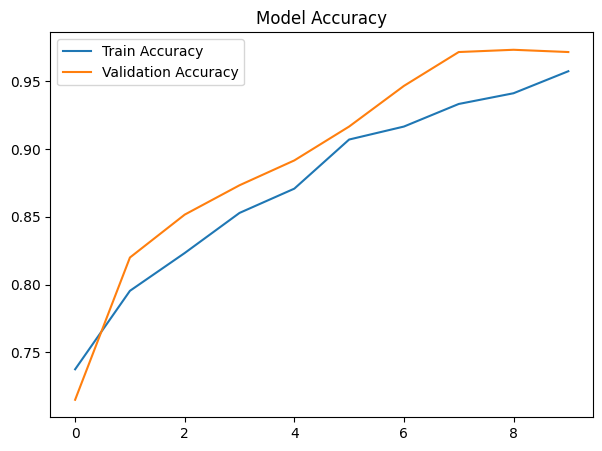

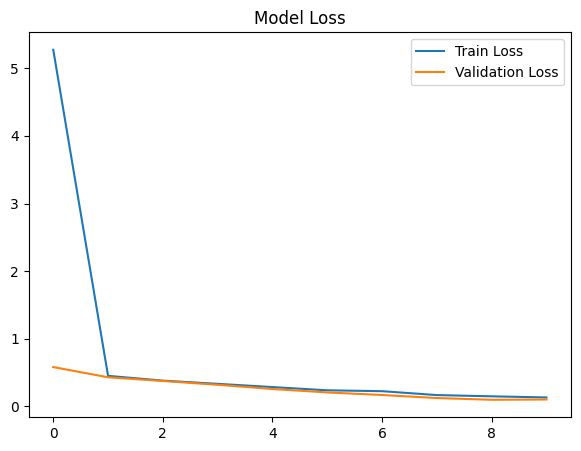

In [12]:
plt.figure(figsize=(7,5))
plt.plot(traning.history['accuracy'], label='Train Accuracy')
plt.plot(traning.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

plt.figure(figsize=(7,5))
plt.plot(traning.history['loss'], label='Train Loss')
plt.plot(traning.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Model Loss')

plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


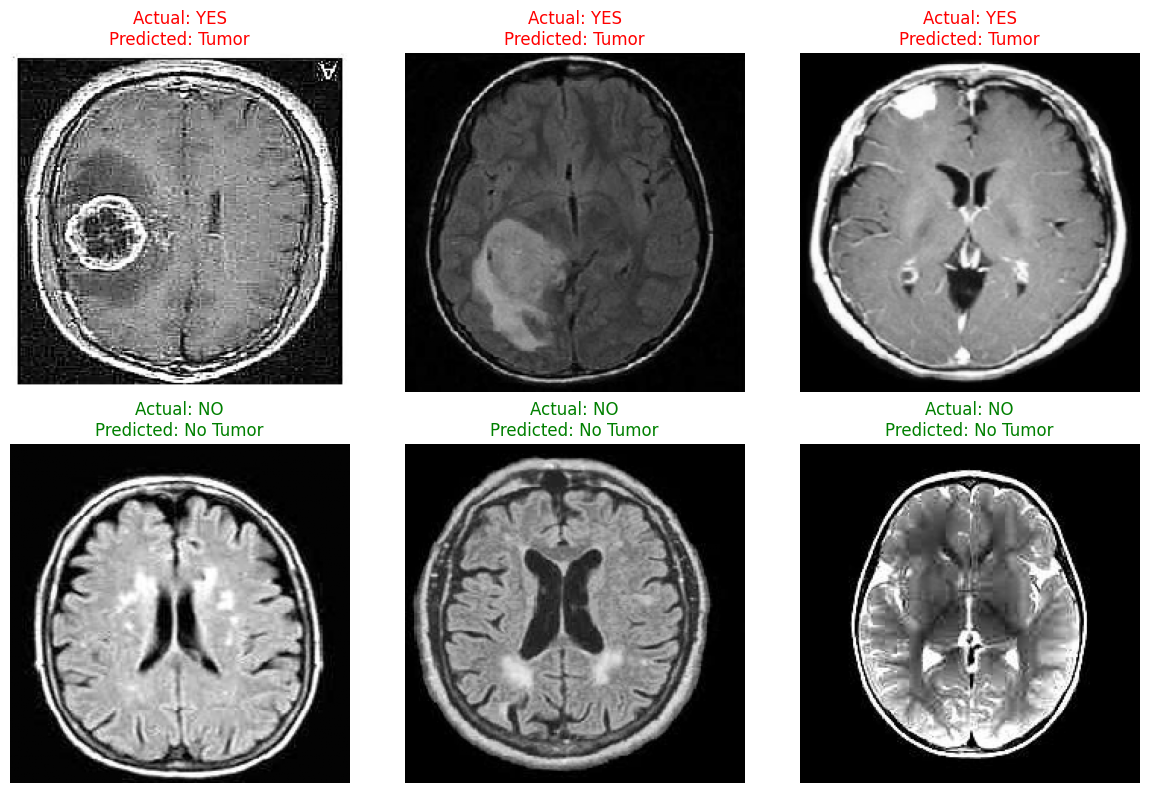

In [13]:
import random
from tensorflow.keras.preprocessing import image

def show_prediction(folder, filename):
    img_path = os.path.join(data_dir, folder, filename)
    img = image.load_img(img_path, target_size=(224,224), color_mode='grayscale')
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) 
    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        result = "Tumor"
        color = "red"
    else:
        result = "No Tumor"
        color = "green"

    plt.imshow(np.array(img).squeeze(), cmap='gray')
    plt.title(f"Actual: {folder.upper()}\nPredicted: {result}", color=color)
    plt.axis('off')


yes_images = random.sample(os.listdir(os.path.join(data_dir, 'yes')), 3)
no_images  = random.sample(os.listdir(os.path.join(data_dir, 'no')), 3)


plt.figure(figsize=(12, 8))

for i, img_name in enumerate(yes_images):
    plt.subplot(2, 3, i + 1)
    show_prediction('yes', img_name)

for i, img_name in enumerate(no_images):
    plt.subplot(2, 3, i + 4)
    show_prediction('no', img_name)

plt.tight_layout()
plt.show()

In [14]:
model.save("brain_tumor_model.h5")